# Sinhala Document OCR — Local Pipeline (Windows + Jupyter)

This notebook runs the **same baseline pipeline** as `notebooks/colab_pipeline.ipynb`, but on your laptop:

1. Setup paths (no git clone)
2. Install Python dependencies
3. Verify Sinhala fonts on Windows
4. Load `configs/local.yaml`
5. Generate synthetic training lines into `data/synthetic/`
6. Train the CRNN recognizer
7. Evaluate CER/WER on the test split
8. Run OCR on an uploaded document in `data/uploads/`

**Tip for MSc experiments:** change `NUM_SAMPLES` and `EPOCHS` in Section 4, then re-run from Section 5 onward.


## 1. Setup — project root and imports

The notebook lives in `notebooks/`, so the repository root is the parent directory. We add it to `sys.path` so `import src...` works.


In [1]:
import os
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()
if (NOTEBOOK_DIR / "local_pipeline.ipynb").exists():
    REPO_ROOT = NOTEBOOK_DIR.parent
elif (NOTEBOOK_DIR / "notebooks" / "local_pipeline.ipynb").exists():
    REPO_ROOT = NOTEBOOK_DIR
else:
    REPO_ROOT = NOTEBOOK_DIR.parent

os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("cwd:", REPO_ROOT)
for name in ("src", "configs", "requirements.txt"):
    p = REPO_ROOT / name
    print(f"  {name}: {'OK' if p.exists() else 'MISSING'}", p)


cwd: C:\Users\ASUS TUF\Projects\sinhala-document-ocr
  src: OK C:\Users\ASUS TUF\Projects\sinhala-document-ocr\src
  configs: OK C:\Users\ASUS TUF\Projects\sinhala-document-ocr\configs
  requirements.txt: OK C:\Users\ASUS TUF\Projects\sinhala-document-ocr\requirements.txt


## 2. Install dependencies

Run once per environment. Key packages: **PyTorch**, **OpenCV**, **Albumentations**, **PyYAML**, **matplotlib**, **Jupyter**.


In [2]:
%pip install -q -r requirements.txt


Note: you may need to restart the kernel to use updated packages.


## 3. Font setup (Windows)

Synthetic lines are rendered with a TrueType font. On Windows, **Nirmala UI** (`Nirmala.ttc`) usually supports Sinhala. **Iskoola Pota** (`iskpota.ttf`) is used when present.


In [3]:
from pathlib import Path

FONT_CANDIDATES = [
    Path(r"C:/Windows/Fonts/Nirmala.ttc"),
    Path(r"C:/Windows/Fonts/iskpota.ttf"),
    REPO_ROOT / "fonts" / "NotoSansSinhala-Regular.ttf",
]

FONT_PATHS = [str(p) for p in FONT_CANDIDATES if p.is_file()]
if not FONT_PATHS:
    print(
        "WARNING: No Sinhala font found. Install Nirmala UI / Iskoola Pota or place Noto Sans Sinhala under fonts/."
    )
else:
    print("Using fonts:")
    for fp in FONT_PATHS:
        print(" ", fp)


Using fonts:
  C:\Windows\Fonts\Nirmala.ttc


## 4. Load configuration

We load `configs/local.yaml` (laptop-friendly defaults). You can override sample count and training epochs here.


In [4]:
import torch
from src.utils.common import load_config, get_logger
from src.utils.display import configure_display_utf8, setup_matplotlib_sinhala

configure_display_utf8()
logger = get_logger("local_pipeline")

CONFIG_PATH = str(REPO_ROOT / "configs" / "local.yaml")
cfg = load_config(CONFIG_PATH)

if FONT_PATHS:
    cfg["synthetic"]["fonts"] = FONT_PATHS

PRIMARY_FONT = FONT_PATHS[0] if FONT_PATHS else None
MPL_FONT = setup_matplotlib_sinhala(PRIMARY_FONT)
if MPL_FONT:
    print("Matplotlib Sinhala font:", MPL_FONT)
else:
    print("WARNING: matplotlib Sinhala font not configured")

CUDA = torch.cuda.is_available()
NUM_SAMPLES = cfg["synthetic"].get("large", {}).get("num_samples", 15000)
if CUDA and NUM_SAMPLES < 15000:
    NUM_SAMPLES = 15000
EPOCHS = cfg["train"]["epochs"]
BATCH_SIZE = cfg["train"]["batch_size"]
if not CUDA and BATCH_SIZE > 16:
    BATCH_SIZE = 16
    print("No CUDA GPU detected — using batch_size =", BATCH_SIZE)

OUT_DIR = cfg["paths"]["synthetic_dir"]
UPLOADS_DIR = cfg["paths"].get("uploads_dir", "data/uploads")
DEBUG_DIR = cfg["paths"].get("debug_dir", "data/debug")

print("config:", CONFIG_PATH)
print("CUDA:", CUDA)
print("NUM_SAMPLES:", NUM_SAMPLES)
print("EPOCHS:", EPOCHS)
print("BATCH_SIZE:", BATCH_SIZE)
print("synthetic output:", OUT_DIR)
print("uploads:", UPLOADS_DIR)


Matplotlib Sinhala font: C:\Windows\Fonts\Nirmala.ttc
config: C:\Users\ASUS TUF\Projects\sinhala-document-ocr\configs\local.yaml
CUDA: True
NUM_SAMPLES: 15000
EPOCHS: 25
BATCH_SIZE: 32
synthetic output: data/synthetic
uploads: data/uploads


## Step A — Generate synthetic data (baseline)

Calls `src.data.synthetic_generator.generate` and writes train/val/test splits under `data/synthetic/`.

Default **15000** samples when CUDA is available (config cell).


In [5]:
from src.data.synthetic_generator import generate, load_word_lists

words = load_word_lists([cfg["paths"]["word_list"], cfg["paths"].get("form_vocab")], warn=logger.warning)
print("Vocabulary entries:", len(words))

counts = generate(
    out_dir=OUT_DIR,
    num_samples=NUM_SAMPLES,
    font_paths=cfg["synthetic"]["fonts"],
    font_sizes=cfg["synthetic"]["font_sizes"],
    words=words,
    min_words=cfg["synthetic"]["min_words"],
    max_words=cfg["synthetic"]["max_words"],
    augment=cfg["synthetic"]["augment"],
    split=cfg["synthetic"]["split"],
    seed=cfg["project"]["seed"],
    logger=logger,
    numeric_ratio=cfg["synthetic"]["numeric_ratio"],
    mixed_ratio=cfg["synthetic"]["mixed_ratio"],
)
print("Split counts:", counts)


10:01:20 | INFO    | local_pipeline | [fonts] using 1 font(s); 485 vocab entries; 15000 samples


Vocabulary entries: 485


render: 100%|████████████████████████████████████████████████████████████████████| 15000/15000 [05:29<00:00, 45.47it/s]
10:06:50 | INFO    | local_pipeline | [split] train: 10500 samples
10:06:50 | INFO    | local_pipeline | [split] val: 2250 samples
10:06:50 | INFO    | local_pipeline | [split] test: 2250 samples
10:06:50 | INFO    | local_pipeline | [done] wrote 15000 images to data/synthetic\images


Split counts: {'train': 10500, 'val': 2250, 'test': 2250}


### Preview a few generated lines

OCR training and metrics use Unicode labels on disk; **this plot is only for visual verification**. With `setup_matplotlib_sinhala()` (Section 4), Sinhala ground-truth text should render in the titles below.


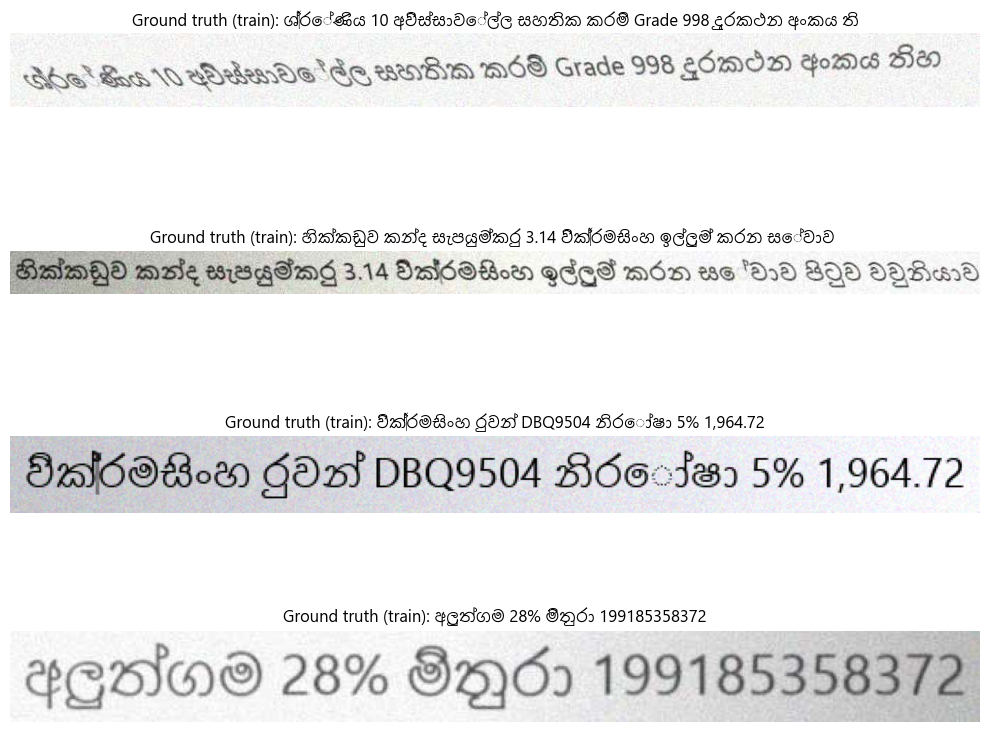

In [6]:
import matplotlib.pyplot as plt
from PIL import Image
from src.data.dataset import read_labels

rows = read_labels(str(REPO_ROOT / OUT_DIR / "train_labels.txt"))
n = min(4, len(rows))
fig, axes = plt.subplots(n, 1, figsize=(10, 2.2 * n))
if n == 1:
    axes = [axes]
for ax, (rel, text) in zip(axes, rows[:n]):
    img = Image.open(REPO_ROOT / OUT_DIR / rel)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Ground truth (train): {text[:60]}")
    ax.axis("off")
plt.tight_layout()
plt.show()


## Step A — Train the CRNN baseline

GPU defaults: **25 epochs**, batch **32** (`configs/local.yaml`). Checkpoints under `models/`.


In [7]:
import subprocess
import sys

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Training device:", DEVICE)
if DEVICE == "cpu":
    print("WARNING: CPU training is slow — consider fewer samples/epochs or a CUDA machine.")

cmd = [
    sys.executable,
    "-m",
    "src.recognition.train",
    "--config",
    CONFIG_PATH,
    f"paths.synthetic_dir={OUT_DIR}",
    f"train.epochs={EPOCHS}",
    f"train.batch_size={BATCH_SIZE}",
    f"train.device={DEVICE}",
]
print(" ".join(cmd))
result = subprocess.run(cmd, cwd=str(REPO_ROOT))
if result.returncode != 0:
    raise SystemExit(result.returncode)


Training device: cuda
C:\Users\ASUS TUF\AppData\Local\Programs\Python\Python313\python.exe -m src.recognition.train --config C:\Users\ASUS TUF\Projects\sinhala-document-ocr\configs\local.yaml paths.synthetic_dir=data/synthetic train.epochs=25 train.batch_size=32 train.device=cuda


## 7. Evaluate on the test set

Reports **Character Error Rate (CER)** and **Word Error Rate (WER)** on `data/synthetic/test_labels.txt`.


In [8]:
from src.charset import Charset
from src.data.dataset import build_dataloader
from src.recognition.model import build_crnn
from src.evaluation.metrics import evaluate_model
from src.utils.common import load_checkpoint, get_device

charset = Charset.load(str(REPO_ROOT / cfg["paths"]["charset_path"]))
device = get_device(DEVICE)
model = build_crnn(charset.num_classes, cfg.get("model"), in_channels=cfg["image"]["channels"]).to(device)
load_checkpoint(str(REPO_ROOT / cfg["paths"]["models_dir"] / "crnn_best.pth"), model, map_location=str(device))
model.eval()

test_loader = build_dataloader(
    str(REPO_ROOT / OUT_DIR / "test_labels.txt"),
    charset,
    batch_size=BATCH_SIZE,
    height=cfg["image"]["height"],
    max_width=cfg["image"]["max_width"],
    channels=cfg["image"]["channels"],
    shuffle=False,
    num_workers=cfg["train"]["num_workers"],
)

report = evaluate_model(model, test_loader, charset, device=device, measure_cpu_time=False)
print(f"TEST  samples={report['num_samples']}  CER={report['cer']:.4f}  WER={report['wer']:.4f}")


TEST  samples=2250  CER=0.0953  WER=0.2713


### Qualitative test predictions (ground truth vs model)

Sinhala strings below use the matplotlib font from Section 4.


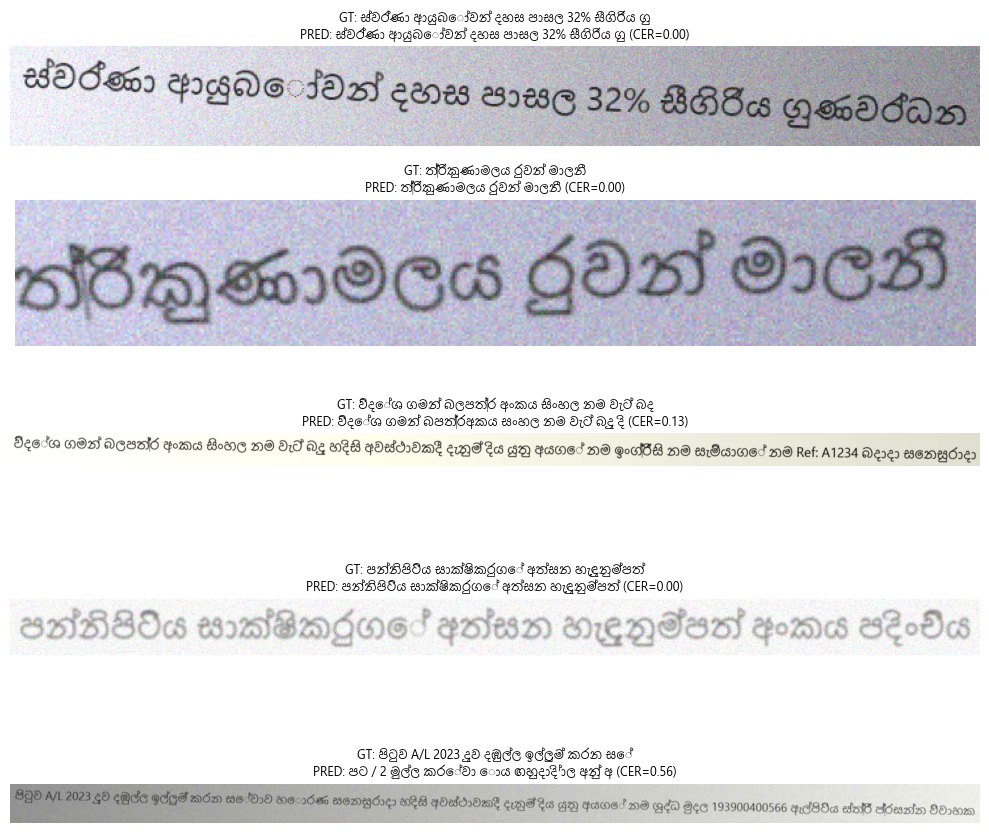

In [9]:
import matplotlib.pyplot as plt
from PIL import Image

test_rows = read_labels(str(REPO_ROOT / OUT_DIR / "test_labels.txt"))
n = min(5, len(test_rows))
fig, axes = plt.subplots(n, 1, figsize=(10, 1.8 * n))
if n == 1:
    axes = [axes]
for ax, (rel, _), sample in zip(axes, test_rows[:n], report["per_sample"][:n]):
    ax.imshow(Image.open(REPO_ROOT / OUT_DIR / rel), cmap="gray")
    ax.set_title(
        f"GT: {sample['ref'][:40]}\nPRED: {sample['hyp'][:40]} (CER={sample['cer']:.2f})",
        fontsize=9,
    )
    ax.axis("off")
plt.tight_layout()
plt.show()


## 8. Upload test — digital scan or file

Use this section for **flatbed scans** or **clean digital exports** (even lighting, minimal skew). Set `LOCAL_UPLOAD_PATH` or drop a file in `data/uploads/`.

For **phone camera** captures (shadows, perspective, uneven light), use **Section C** below.


In [10]:
import glob
from tkinter import Tk, filedialog

SECTION8_PICK_FILE = False  # True: tkinter file dialog on Windows/local Jupyter
LOCAL_UPLOAD_PATH = ""  # e.g. r"C:\\Users\\You\\Pictures\\scan.png"

INVERT_IF_DARK_BG = True
SKIP_DOCUMENT_BINARIZE = True
USE_WHOLE_IMAGE_IF_ONE_LINE = True

upload_root = REPO_ROOT / UPLOADS_DIR
upload_root.mkdir(parents=True, exist_ok=True)

UPLOADED_IMAGE_PATH = LOCAL_UPLOAD_PATH.strip()
if SECTION8_PICK_FILE:
    _root = Tk()
    _root.withdraw()
    _root.attributes("-topmost", True)
    picked = filedialog.askopenfilename(
        title="Select document image",
        filetypes=[("Images", "*.png;*.jpg;*.jpeg;*.bmp;*.tif;*.tiff"), ("All", "*.*")],
    )
    _root.destroy()
    if picked:
        UPLOADED_IMAGE_PATH = picked

if not UPLOADED_IMAGE_PATH:
    for ext in ("*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff"):
        hits = sorted(upload_root.glob(ext))
        if hits:
            UPLOADED_IMAGE_PATH = str(hits[-1])
            break

if not UPLOADED_IMAGE_PATH or not Path(UPLOADED_IMAGE_PATH).is_file():
    print(
        "Set LOCAL_UPLOAD_PATH, enable SECTION8_PICK_FILE, or copy an image into",
        upload_root,
        "then re-run this cell.",
    )
else:
    print("Using:", UPLOADED_IMAGE_PATH)


Using: C:\Users\ASUS TUF\Projects\sinhala-document-ocr\data\uploads\test2.png


In [11]:
import cv2
import matplotlib.pyplot as plt
import torch

from src.charset import Charset
from src.detection.text_detection import OpenCVLineDetector, crop_lines, draw_boxes
from src.preprocessing.preprocess import preprocess_document
from src.recognition.inference import inference_options_from_config, prepared_line_for_display
from src.recognition.model import build_crnn
from src.recognition.predict import predict_line_array
from src.utils.common import get_device, load_checkpoint, resolve_recognition_checkpoint

if not UPLOADED_IMAGE_PATH or not Path(UPLOADED_IMAGE_PATH).is_file():
    raise RuntimeError("Configure an upload path in the cell above.")

finetuned_ckpt = REPO_ROOT / cfg["paths"]["models_dir"] / "crnn_finetuned.pth"
_inf_cfg = load_config(str(REPO_ROOT / "configs" / "finetune.yaml")) if finetuned_ckpt.is_file() else cfg
INF_OPTS = inference_options_from_config(_inf_cfg)
RECOGNITION_HEIGHT = INF_OPTS["height"]
print("Recognition height:", RECOGNITION_HEIGHT)
CHECKPOINT_PATH = Path(resolve_recognition_checkpoint(cfg, REPO_ROOT))
print("Recognition checkpoint:", CHECKPOINT_PATH.name)
CHARSET_PATH = REPO_ROOT / cfg["paths"]["charset_path"]

device = get_device(DEVICE)
charset = Charset.load(str(CHARSET_PATH))
model = build_crnn(charset.num_classes, cfg.get("model"), in_channels=INF_OPTS["channels"]).to(device)
load_checkpoint(str(CHECKPOINT_PATH), model, map_location=str(device))
model.eval()

page_bgr = cv2.imread(UPLOADED_IMAGE_PATH, cv2.IMREAD_COLOR)
page_gray = cv2.cvtColor(page_bgr, cv2.COLOR_BGR2GRAY)
page_for_det = page_gray if SKIP_DOCUMENT_BINARIZE else preprocess_document(page_bgr)

skip_detection = False
if USE_WHOLE_IMAGE_IF_ONE_LINE:
    ph, pw = page_gray.shape[:2]
    if pw >= 4 * ph or ph <= 3 * max(int(cfg["detection"]["min_line_height"]), 1):
        skip_detection = True
        print("[info] Single-line heuristic: using full image.")

if skip_detection:
    boxes = [(0, 0, page_gray.shape[1], page_gray.shape[0])]
else:
    detector = OpenCVLineDetector(
        dilate_kernel=tuple(cfg["detection"]["dilate_kernel"]),
        min_line_height=int(cfg["detection"]["min_line_height"]),
        min_line_width=int(cfg["detection"]["min_line_width"]),
    )
    boxes = detector.detect(page_for_det) or [(0, 0, page_for_det.shape[1], page_for_det.shape[0])]

line_crops = crop_lines(
    page_gray,
    boxes,
    padding_x=int(cfg["detection"].get("crop_padding_x", 10)),
    padding_y=int(cfg["detection"].get("crop_padding_y", 5)),
    min_crop_height=int(cfg["detection"].get("min_crop_height", 14)),
)


page_with_boxes = draw_boxes(page_bgr, boxes)
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(page_with_boxes, cv2.COLOR_BGR2RGB))
plt.title("Detected lines (Section 8)")
plt.axis("off")
plt.show()

upload_predictions = []
auto_inv = INVERT_IF_DARK_BG and INF_OPTS["auto_invert"]
with torch.no_grad():
    for i, crop in enumerate(line_crops):
        text = predict_line_array(
            model,
            charset,
            crop,
            INF_OPTS["height"],
            INF_OPTS["max_width"],
            INF_OPTS["channels"],
            device,
            auto_invert=auto_inv,
            denoise=INF_OPTS["denoise"],
            min_model_width=INF_OPTS.get("min_model_width", 0),
            pad_to_height=INF_OPTS.get("pad_to_height", True),
            decode_mode=INF_OPTS.get("decode", "greedy"),
            beam_width=int(INF_OPTS.get("beam_width", 10)),
            warn_garbage=True,
        )
        upload_predictions.append({"line": i + 1, "text": text, "crop": crop.copy()})
        print(f"Line {i + 1}:", text)

print("--- Full transcription ---")
print("\n".join(p["text"] for p in upload_predictions))

n_up = len(upload_predictions)
if n_up:
    fig, axes = plt.subplots(n_up, 1, figsize=(10, 1.8 * n_up))
    if n_up == 1:
        axes = [axes]
    for ax, row in zip(axes, upload_predictions):
        ax.imshow(row["crop"], cmap="gray")
        ax.set_title(f"Line {row['line']}: {row['text'][:80]}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()


Recognition height: 64
Recognition checkpoint: crnn_finetuned.pth


AttributeError: module 'math' has no attribute 'logaddexp'

## Section B — Fine-tune on real poem (Kanyawee)

Ground truth is in `data/real/labels/poem_kanyawee.txt` (**user-corrected transcripts**, e.g. line 2 has **no** trailing full stop). Fine-tuning uses poem lines repeated **50×**, saves `models/crnn_finetuned.pth`, and inference height **64** (`configs/finetune.yaml`).

Set `FT_RUN_PREP = False` to fine-tune from existing crops/labels without re-running detection (existing `poem_line_*.png` files are never overwritten).


In [ ]:
FT_POEM_REPEAT = 50
FT_SYN_MAX = 3000
FT_USE_REAL_ONLY = False  # set True for poem-only finetune
FT_RUN_PREP = False  # True: run prepare_poem_dataset.py from POEM_IMAGE

import subprocess
import sys

POEM_LABELS = REPO_ROOT / "data" / "real" / "labels" / "poem_kanyawee.txt"
if not POEM_LABELS.is_file():
    raise FileNotFoundError(POEM_LABELS)
print("Poem labels:", POEM_LABELS, "(", len(POEM_LABELS.read_text(encoding="utf-8").strip().splitlines()), "lines)")

if FT_RUN_PREP:
    POEM_IMAGE = str(REPO_ROOT / "data" / "uploads" / "test2.png")
    if not Path(POEM_IMAGE).is_file() and globals().get("UPLOADED_IMAGE_PATH"):
        POEM_IMAGE = UPLOADED_IMAGE_PATH
    prep_cmd = [sys.executable, "scripts/prepare_poem_dataset.py", "--image", POEM_IMAGE]
    print(" ".join(prep_cmd))
    subprocess.run(prep_cmd, cwd=str(REPO_ROOT), check=True)
else:
    print("Skipping prepare_poem_dataset.py — using existing labels/crops.")


In [ ]:
poem_labels = str(REPO_ROOT / "data" / "real" / "labels" / "poem_kanyawee.txt")
finetune_cmd = [
    sys.executable,
    "-m",
    "src.recognition.train",
    "--config",
    str(REPO_ROOT / "configs" / "finetune.yaml"),
    "--resume",
    str(REPO_ROOT / cfg["paths"]["models_dir"] / "crnn_best.pth"),
    "--extra-labels",
    poem_labels,
    f"train.extra_label_repeat={FT_POEM_REPEAT}",
    f"train.synthetic_train_max={FT_SYN_MAX}",
    "inference.image_height=64",
    f"train.device={DEVICE}",
]
if FT_USE_REAL_ONLY:
    finetune_cmd.append("--finetune-real-only")
print(" ".join(finetune_cmd))
subprocess.run(finetune_cmd, cwd=str(REPO_ROOT), check=True)
print("Finetuned checkpoint:", REPO_ROOT / cfg["paths"]["models_dir"] / "crnn_finetuned.pth")


In [ ]:
from src.data.dataset import read_labels
from src.evaluation.metrics import cer, corpus_cer
from src.recognition.inference import inference_options_from_config
from src.recognition.predict import predict_line_array
from src.utils.common import load_config

INF_OPTS = inference_options_from_config(load_config(str(REPO_ROOT / "configs" / "finetune.yaml")))
print("Poem eval inference height:", INF_OPTS["height"], "decode:", INF_OPTS.get("decode", "greedy"))

POEM_GT_PATH = REPO_ROOT / "data" / "real" / "labels" / "poem_kanyawee.txt"
POEM_GT = [t for _p, t in read_labels(str(POEM_GT_PATH))] if POEM_GT_PATH.is_file() else []


def run_upload_ocr(checkpoint_name: str):
    ckpt = REPO_ROOT / cfg["paths"]["models_dir"] / checkpoint_name
    charset = Charset.load(str(CHARSET_PATH))
    m = build_crnn(charset.num_classes, cfg.get("model"), in_channels=INF_OPTS["channels"]).to(device)
    load_checkpoint(str(ckpt), m, map_location=str(device))
    m.eval()
    preds = []
    with torch.no_grad():
        for crop in line_crops:
            preds.append(
                predict_line_array(
                    m, charset, crop, INF_OPTS["height"], INF_OPTS["max_width"],
                    INF_OPTS["channels"], device, auto_invert=auto_inv,
                    denoise=INF_OPTS["denoise"],
                    min_model_width=INF_OPTS.get("min_model_width", 0),
                    pad_to_height=INF_OPTS.get("pad_to_height", True),
                    decode_mode=INF_OPTS.get("decode", "greedy"),
                    beam_width=int(INF_OPTS.get("beam_width", 10)),
                )
            )
    return preds


if POEM_GT and line_crops:
    n = min(len(POEM_GT), len(line_crops))
    before = run_upload_ocr("crnn_best.pth")
    after_path = REPO_ROOT / cfg["paths"]["models_dir"] / "crnn_finetuned.pth"
    after = run_upload_ocr("crnn_finetuned.pth") if after_path.is_file() else [""] * len(line_crops)
    rows = []
    cer_sum_b = cer_sum_a = 0.0
    for i in range(n):
        ref = POEM_GT[i]
        pb = before[i] if i < len(before) else ""
        pa = after[i] if i < len(after) else ""
        cb = cer(ref, pb)
        ca = cer(ref, pa)
        cer_sum_b += cb
        cer_sum_a += ca
        rows.append({
            "line": i + 1,
            "cer_before": round(cb, 4),
            "cer_after": round(ca, 4),
            "gt": ref,
            "pred_after": pa,
        })
    print(f"Mean CER before: {cer_sum_b / n:.4f} | after finetune: {cer_sum_a / n:.4f}")
    print(f"Corpus CER after finetune: {corpus_cer(POEM_GT[:n], after[:n]):.4f}")
    try:
        import pandas as pd
        display(pd.DataFrame(rows)[["line", "cer_before", "cer_after", "pred_after"]])
    except ImportError:
        for r in rows:
            print(r)

    if after_path.is_file():
        upload_predictions = [
            {"line": i + 1, "text": after[i], "crop": line_crops[i].copy()}
            for i in range(len(line_crops))
        ]
        print("\n--- Upload OCR (crnn_finetuned.pth) ---")
        print("\n".join(p["text"] for p in upload_predictions))
else:
    print("Run prepare + upload OCR first, or missing poem labels.")


## Section C — Test on real captured photo

Phone **camera** photos differ from scans: uneven lighting, shadows, perspective skew, and glare. This section runs the full pipeline (preprocess → line detection → OCR) on a **real capture**.

Use **Section 8** for digital scans; use **Section C** for handheld photos.


In [ ]:
import shutil
from datetime import datetime, timezone
from tkinter import Tk, filedialog

TEST_MODE = "upload"  # "upload" | "file_path"
REAL_PHOTO_PATH = ""  # e.g. data/uploads/photo_poem.jpg if already saved
USE_FINETUNED = True  # crnn_finetuned.pth if exists else crnn_best.pth
COMPARE_TO_POEM_GT = False  # set True only when testing same poem page
POEM_GT_LABELS = "data/real/labels/poem_kanyawee.txt"  # for CER if same content

INVERT_IF_DARK_BG_C = True
SKIP_DOCUMENT_BINARIZE_C = True

upload_root = REPO_ROOT / UPLOADS_DIR
upload_root.mkdir(parents=True, exist_ok=True)

real_photo_path = REAL_PHOTO_PATH.strip()
if TEST_MODE == "upload":
    _root = Tk()
    _root.withdraw()
    _root.attributes("-topmost", True)
    picked = filedialog.askopenfilename(
        title="Select real captured photo",
        filetypes=[("Images", "*.png;*.jpg;*.jpeg;*.bmp;*.tif;*.tiff"), ("All", "*.*")],
    )
    _root.destroy()
    if not picked:
        raise RuntimeError("No file selected.")
    stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    dest = upload_root / f"real_capture_{stamp}{Path(picked).suffix.lower() or '.jpg'}"
    shutil.copy2(picked, dest)
    real_photo_path = str(dest)
    print("Copied to", dest)
elif TEST_MODE == "file_path":
    if not real_photo_path:
        raise RuntimeError("Set REAL_PHOTO_PATH for file_path mode.")
    p = Path(real_photo_path)
    if not p.is_absolute():
        p = REPO_ROOT / p
    if not p.is_file():
        raise FileNotFoundError(p)
    real_photo_path = str(p)
else:
    raise ValueError(f"Unknown TEST_MODE: {TEST_MODE}")

print("Real photo:", real_photo_path)


In [ ]:
import json
import cv2
import matplotlib.pyplot as plt
import torch

from src.charset import Charset
from src.data.dataset import read_labels
from src.detection.text_detection import OpenCVLineDetector, crop_lines, draw_boxes
from src.evaluation.metrics import cer, corpus_cer
from src.preprocessing.preprocess import preprocess_document
from src.recognition.inference import inference_options_from_config
from src.recognition.model import build_crnn
from src.recognition.predict import predict_line_array
from src.utils.common import get_device, load_checkpoint, load_config
from src.utils.display import setup_matplotlib_sinhala

setup_matplotlib_sinhala(PRIMARY_FONT if "PRIMARY_FONT" in globals() else None)

finetune_cfg = load_config(str(REPO_ROOT / "configs" / "finetune.yaml"))
INF_OPTS_C = inference_options_from_config(finetune_cfg)
print("Inference height:", INF_OPTS_C["height"], "auto_invert:", INF_OPTS_C.get("auto_invert"))

models_dir = REPO_ROOT / cfg["paths"]["models_dir"]
if USE_FINETUNED and (models_dir / "crnn_finetuned.pth").is_file():
    ckpt_path = models_dir / "crnn_finetuned.pth"
else:
    ckpt_path = models_dir / "crnn_best.pth"
print("Checkpoint:", ckpt_path.name)

CHARSET_PATH = REPO_ROOT / cfg["paths"]["charset_path"]
device = get_device(DEVICE)
charset = Charset.load(str(CHARSET_PATH))
model_c = build_crnn(charset.num_classes, cfg.get("model"), in_channels=INF_OPTS_C["channels"]).to(device)
load_checkpoint(str(ckpt_path), model_c, map_location=str(device))
model_c.eval()

page_bgr = cv2.imread(real_photo_path, cv2.IMREAD_COLOR)
if page_bgr is None:
    raise RuntimeError(f"Could not read {real_photo_path}")
page_gray = cv2.cvtColor(page_bgr, cv2.COLOR_BGR2GRAY)
page_for_det = page_gray if SKIP_DOCUMENT_BINARIZE_C else preprocess_document(page_bgr)

detector = OpenCVLineDetector(
    dilate_kernel=tuple(cfg["detection"]["dilate_kernel"]),
    min_line_height=int(cfg["detection"]["min_line_height"]),
    min_line_width=int(cfg["detection"]["min_line_width"]),
)
boxes = detector.detect(page_for_det) or [(0, 0, page_for_det.shape[1], page_for_det.shape[0])]
line_crops_c = crop_lines(
    page_gray,
    boxes,
    padding_x=int(cfg["detection"].get("crop_padding_x", 10)),
    padding_y=int(cfg["detection"].get("crop_padding_y", 5)),
    min_crop_height=int(cfg["detection"].get("min_crop_height", 14)),
)

page_with_boxes = draw_boxes(page_bgr, boxes)
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(page_with_boxes, cv2.COLOR_BGR2RGB))
plt.title("Real capture — detected lines")
plt.axis("off")
plt.show()

auto_inv_c = INVERT_IF_DARK_BG_C and INF_OPTS_C["auto_invert"]
real_capture_predictions = []
with torch.no_grad():
    for i, crop in enumerate(line_crops_c):
        text = predict_line_array(
            model_c,
            charset,
            crop,
            INF_OPTS_C["height"],
            INF_OPTS_C["max_width"],
            INF_OPTS_C["channels"],
            device,
            auto_invert=auto_inv_c,
            denoise=INF_OPTS_C["denoise"],
            min_model_width=INF_OPTS_C.get("min_model_width", 0),
            pad_to_height=INF_OPTS_C.get("pad_to_height", True),
            decode_mode=INF_OPTS_C.get("decode", "greedy"),
            beam_width=int(INF_OPTS_C.get("beam_width", 10)),
            warn_garbage=True,
        )
        real_capture_predictions.append({"line": i + 1, "text": text, "crop": crop.copy()})
        print(f"Line {i + 1}:", text)

gt_path = REPO_ROOT / POEM_GT_LABELS
if COMPARE_TO_POEM_GT and gt_path.is_file():
    poem_gt = [t for _p, t in read_labels(str(gt_path))]
    n = min(len(poem_gt), len(real_capture_predictions))
    if n and n == len(poem_gt) == len(real_capture_predictions):
        preds = [r["text"] for r in real_capture_predictions]
        print(f"Poem CER: {corpus_cer(poem_gt, preds):.4f}")
        for i in range(n):
            print(f"  line {i+1} CER {cer(poem_gt[i], preds[i]):.4f}")
    else:
        print(
            "COMPARE_TO_POEM_GT: line count mismatch — showing predictions only.",
            f"detected={len(real_capture_predictions)} gt={len(poem_gt)}",
        )

n_rc = len(real_capture_predictions)
if n_rc:
    fig, axes = plt.subplots(n_rc, 1, figsize=(10, 1.8 * n_rc))
    if n_rc == 1:
        axes = [axes]
    for ax, row in zip(axes, real_capture_predictions):
        ax.imshow(row["crop"], cmap="gray")
        ax.set_title(f"Line {row['line']}: {row['text'][:80]}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

debug_root = REPO_ROOT / DEBUG_DIR
stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
run_dir = debug_root / f"real_capture_{stamp}"
run_dir.mkdir(parents=True, exist_ok=True)
cv2.imwrite(str(run_dir / "source.jpg"), page_bgr)
cv2.imwrite(str(run_dir / "boxes.jpg"), page_with_boxes)
summary = {
    "source_image": real_photo_path,
    "checkpoint": ckpt_path.name,
    "compare_poem_gt": COMPARE_TO_POEM_GT,
    "lines": [{"line": p["line"], "text": p["text"]} for p in real_capture_predictions],
}
(run_dir / "predictions.json").write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
for p in real_capture_predictions:
    cv2.imwrite(str(run_dir / f"line_{p['line']:02d}.png"), p["crop"])
print("Saved debug outputs to", run_dir)


## 9. Optional — save debug outputs

Writes a JSON summary and cropped line images to `data/debug/` for your thesis appendix or error analysis.


In [ ]:
import json
from datetime import datetime, timezone

debug_root = REPO_ROOT / DEBUG_DIR
debug_root.mkdir(parents=True, exist_ok=True)
stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
run_dir = debug_root / f"upload_{stamp}"
run_dir.mkdir(parents=True, exist_ok=True)

if upload_predictions:
    summary = {
        "source_image": UPLOADED_IMAGE_PATH,
        "lines": [{"line": p["line"], "text": p["text"]} for p in upload_predictions],
        "test_cer": globals().get("report", {}).get("cer"),
        "test_wer": globals().get("report", {}).get("wer"),
    }
    (run_dir / "predictions.json").write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
    for p in upload_predictions:
        cv2.imwrite(str(run_dir / f"line_{p['line']:02d}.png"), p["crop"])
    print("Saved debug outputs to", run_dir)
else:
    print("No predictions to save — run Section 8 first.")
